# 04 · Continuous segmentation — which frames are a word?
Trained on synthetic sentences built from isolated TTRS signs (same signer, 1–2.5× faster, interpolated transitions, compact signing space). Validation uses a **held-out signer**.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'modules').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['Tahoma', 'Leelawadee UI', 'DejaVu Sans']
from IPython.display import display, Image, Audio, Markdown
from modules.utils import ART, read_json
REP, V4, MAN4 = ART / 'reports', ART / 'v4', ART / 'manifests_v4'
pd.set_option('display.max_colwidth', 80)

held-out signer: S_ttrs_00


,learned,heuristic
boundary_f1,0.716201,0.278127
frame_acc,0.921769,NaN
count_abs_err,0.360000,1.686667


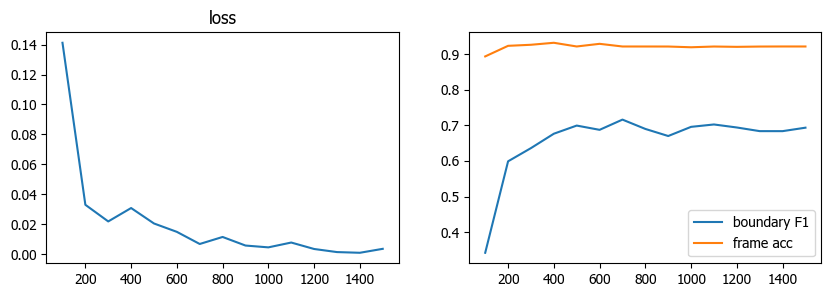

In [2]:
seg = read_json(REP/'v4_segmentation.json')
print('held-out signer:', seg['val_signer']); display(pd.DataFrame({'learned': seg['val_learned'], 'heuristic': seg['val_heuristic']}))
h = pd.DataFrame(seg['hist']); fig, ax = plt.subplots(1, 2, figsize=(10,3)); ax[0].plot(h.step, h.loss); ax[0].set_title('loss'); ax[1].plot(h.step, h.boundary_f1, label='boundary F1'); ax[1].plot(h.step, h.frame_acc, label='frame acc'); ax[1].legend(); plt.show()

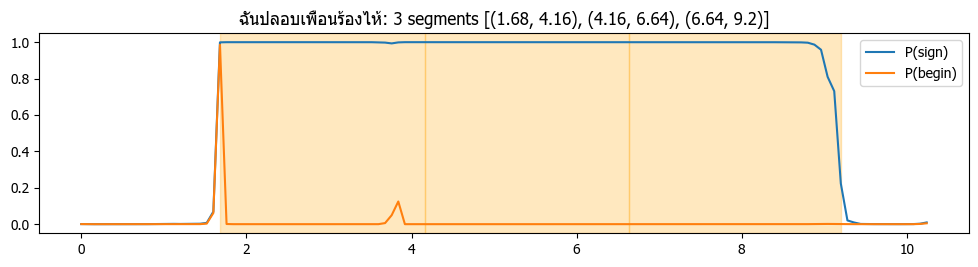

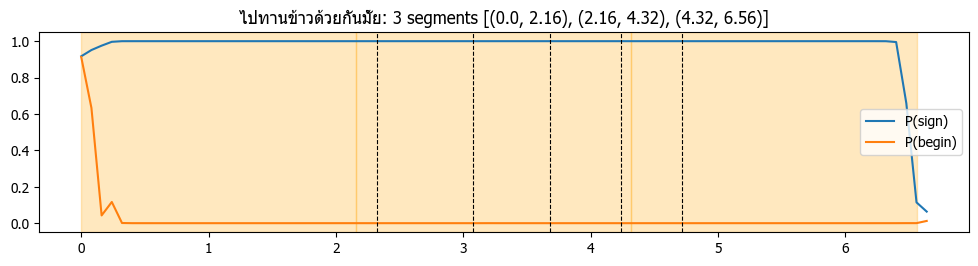

In [3]:
import torch
from modules.segment import Segmenter, decode_segments, sequence_features
from modules.unisign import UniSignEncoder
from modules.recognize import load_pose
enc = UniSignEncoder('wlasl').eval(); model = Segmenter().cuda(); model.load_state_dict(torch.load(V4/'segmenter.pt')); model.eval()
text_events = {'ไปทานข้าวด้วยกันมั้ย': [2.32, 3.08, 3.68, 4.24, 4.72]}  # on-screen text changes (evaluation only)
for stem in ['ฉันปลอบเพื่อนร้องไห้', 'ไปทานข้าวด้วยกันมั้ย']:
    kp, sc, hw, fps = load_pose(ART/'pose_v4'/f'test_{stem}_125.npz')
    x = sequence_features(enc, kp, sc, hw)
    with torch.no_grad(): prob = model(torch.from_numpy(x)[None].cuda()).softmax(-1)[0].cpu().numpy()
    segs = decode_segments(prob); t = np.arange(len(prob))/12.5
    plt.figure(figsize=(12, 2.6)); plt.plot(t, prob[:,1]+prob[:,2], label='P(sign)'); plt.plot(t, prob[:,1], label='P(begin)')
    for a, b in segs: plt.axvspan(a/12.5, b/12.5, color='orange', alpha=0.25)
    for e in text_events.get(stem, []): plt.axvline(e, color='k', ls='--', lw=0.8)
    plt.title(f'{stem}: {len(segs)} segments ' + str([(round(a/12.5,2), round(b/12.5,2)) for a,b in segs])); plt.legend(); plt.show()